# Combined Notebook: S&P 500 Analysis with Macroeconomic Indicators

This notebook integrates multiple analyses:
- CPI inflation, unemployment, and market returns (monthly & 10-year rolling)
- GDP output gap, yield curve, recession probability model, sector sensitivity
- 10-year treasury yield slope, GDP change smoothing, trading volume smoothing
- Monthly seasonality, yearly trends, sector/industry/company performance

All data is loaded once and reused across analyses.

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy.sparse import SparseEfficiencyWarning

# Settings
warnings.simplefilter('ignore', SparseEfficiencyWarning)
warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 200)
pd.options.display.float_format = '{:,.2f}'.format
%matplotlib inline

## 2. Define Helper Functions

In [2]:
def monthly_resample(df, date_col='DATE', value_col=None):
    """Resample dataframe to monthly start (MS) mean."""
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    if value_col:
        return df[[value_col]].resample('MS').mean().reset_index()
    else:
        return df.resample('MS').mean().reset_index()

def slice_dates(df, start, end, date_col='DATE'):
    """Filter dataframe between two dates."""
    return df[(df[date_col] >= start) & (df[date_col] <= end)]

def horizontal_rule(ax=None):
    """Add horizontal line at y=0."""
    if ax is None:
        ax = plt.gca()
    ax.axhline(0, color='black', linestyle='--', linewidth=2)

def smooth_series(df, column, window, center=True):
    """Rolling mean smoother."""
    return df[column].rolling(window=window, center=center).mean()

## 3. Load Raw Data

All files are assumed to be in `./sp500_comprehensive/` directory.

In [3]:
data_dir = "./sp500_comprehensive/"

# Economic indicators (monthly)
df_cpi = pd.read_csv(data_dir + "economic_CPI.csv", index_col="DATE", parse_dates=["DATE"])
df_unrate = pd.read_csv(data_dir + "economic_UNRATE.csv", index_col="DATE", parse_dates=["DATE"])
df_dgs10 = pd.read_csv(data_dir + "economic_DGS10.csv", index_col="DATE", parse_dates=["DATE"])
df_fedfunds = pd.read_csv(data_dir + "economic_FEDFUNDS.csv", index_col="DATE", parse_dates=["DATE"])
df_gdp = pd.read_csv(data_dir + "economic_GDP.csv", index_col="DATE", parse_dates=["DATE"])
df_vix = pd.read_csv(data_dir + "economic_VIX.csv", index_col="DATE", parse_dates=["DATE"])

# S&P 500 index daily
df_sp500_index = pd.read_csv(data_dir + "sp500_index.csv", header=0,
                              names=['DATE', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker'],
                              index_col="DATE", parse_dates=["DATE"])

# S&P 500 individual stocks (master)
df_sp500_master = pd.read_csv(data_dir + "sp500_master_50years.csv")
df_sp500_master['Date'] = pd.to_datetime(df_sp500_master['Date'], utc=True).dt.tz_localize(None).dt.normalize()

## 4. Data Cleaning and Initial Preprocessing

### 4.1 Forward fill monthly data

In [4]:
df_cpi["CPIAUCSL"] = df_cpi["CPIAUCSL"].ffill()
df_unrate["UNRATE"] = df_unrate["UNRATE"].ffill()

### 4.2 Create master daily dataframe

In [5]:
# Generate all possible dates from min to max year
start_date = pd.to_datetime(df_sp500_master['Date'].min().year, format='%Y')
end_date = pd.to_datetime(df_sp500_master['Date'].max(), format='%Y-%m-%d')
dates = pd.date_range(start=start_date, end=end_date, freq="D")
df_master = pd.DataFrame(index=dates)
df_master.index = df_master.index.floor('D')
df_master.index.name = 'DATE'

# Merge S&P 500 index and VIX
df_master = df_master.merge(df_sp500_index[['Close']].rename(columns={'Close':'GSPC'}), 
                            left_index=True, right_index=True, how='left')
df_master = df_master.merge(df_vix['VIXCLS'], left_index=True, right_index=True, how='left')
df_master = df_master.merge(df_dgs10['DGS10'], left_index=True, right_index=True, how='left')
df_master = df_master.merge(df_cpi['CPIAUCSL'], left_index=True, right_index=True, how='left')
df_master = df_master.merge(df_fedfunds['FEDFUNDS'], left_index=True, right_index=True, how='left')
df_master = df_master.merge(df_unrate['UNRATE'], left_index=True, right_index=True, how='left')
df_master = df_master.merge(df_gdp['GDP'], left_index=True, right_index=True, how='left')

# Forward fill unemployment (monthly -> daily)
df_master['UNRATE_ffilled'] = df_master['UNRATE'].ffill()
df_master['DGS10_ffilled'] = df_master['DGS10'].ffill()

### 4.3 Feature engineering on master dataframe

In [6]:
# Recession indicator using Sahm Rule (3-month MA of unemployment rises 0.5% above 12-month low)
df_master['UNRATE_3moMA'] = df_master['UNRATE_ffilled'].rolling(window=63).mean()   # ~3 trading months
df_master['UNRATE_12moLow'] = df_master['UNRATE_3moMA'].rolling(window=252).min()   # ~12 months
df_master['RECESSION'] = (df_master['UNRATE_3moMA'] - df_master['UNRATE_12moLow'] >= 0.5).astype(int)

# Yield spread (10Y Treasury - Fed Funds)
df_master['YieldSpread'] = df_master['DGS10_ffilled'] - df_master['FEDFUNDS']

# Monthly resampled data
df_monthly = df_master.resample('MS').first().dropna(subset=['CPIAUCSL', 'UNRATE'])
df_monthly['CPI_yearly_inflation'] = df_monthly['CPIAUCSL'].pct_change(12) * 100
df_monthly['Monthly_returns'] = df_monthly['GSPC'].pct_change() * 100
df_monthly.dropna(subset=['CPI_yearly_inflation', 'Monthly_returns'], inplace=True)

# 10-year rolling metrics
df_monthly['10Y_return'] = df_monthly['Monthly_returns'].rolling(120).sum()
df_monthly['10Y_inflation'] = df_monthly['CPI_yearly_inflation'].rolling(120).mean()

# Quarterly resampled data for GDP/output gap analysis
df_quarterly = df_master.resample('QS').first().iloc[:-1]  # drop last incomplete quarter
df_quarterly['GDPlog'] = np.log(df_quarterly['GDP'])
df_quarterly['GDPGrowth'] = df_quarterly['GDP'].pct_change()

# Hodrick-Prescott filter for output gap
cycle, trend = sm.tsa.filters.hpfilter(df_quarterly['GDPlog'].dropna(), lamb=1600)
df_quarterly.loc[df_quarterly['GDPlog'].dropna().index, 'OutputGap'] = cycle
df_quarterly.loc[df_quarterly['GDPlog'].dropna().index, 'PotentialGDP'] = trend

# Identify recession periods for shading
recession_periods = []
start = None
for date, row in df_quarterly.iterrows():
    if row['RECESSION'] == 1 and start is None:
        start = date
    elif row['RECESSION'] == 0 and start is not None:
        recession_periods.append((start, date))
        start = None

### 4.4 Prepare stock master for detailed analysis

In [7]:
df_stocks = df_sp500_master.copy()

# Drop pre-computed columns that are not needed
cols_to_drop = ['Daily_return', 'Monthly_return', 'Sma200', 'Sma50', 'Volatility', 'Weekly_return']
df_stocks = df_stocks.drop(columns=[c for c in cols_to_drop if c in df_stocks.columns], errors='ignore')

# Ensure Date is datetime and sorted
df_stocks['Date'] = pd.to_datetime(df_stocks['Date'], utc=True)
df_stocks = df_stocks.sort_values(['Ticker', 'Date'])

# Compute daily returns (log returns)
df_stocks['Returns'] = np.log(df_stocks['Close'] / df_stocks.groupby('Ticker')['Close'].shift(1))
df_stocks = df_stocks.dropna(subset=['Returns'])

# Extract date components
df_stocks['Month'] = df_stocks['Date'].dt.month
df_stocks['Month_Name'] = df_stocks['Date'].dt.strftime('%B')
df_stocks['Year'] = df_stocks['Date'].dt.year

# Rolling volatilities
df_stocks['30_days_vol'] = df_stocks.groupby('Ticker')['Returns'].rolling(30).std().reset_index(0, drop=True)
df_stocks['60_days_vol'] = df_stocks.groupby('Ticker')['Returns'].rolling(60).std().reset_index(0, drop=True)
df_stocks['252_days_vol'] = df_stocks.groupby('Ticker')['Returns'].rolling(252).std().reset_index(0, drop=True)

# Sector mapping from master data
df_sectors = df_sp500_master[['Ticker', 'Name', 'Sector', 'Industry']].drop_duplicates().set_index('Ticker')
df_stocks = df_stocks.merge(df_sectors[['Sector', 'Industry']], left_on='Ticker', right_index=True, how='left')

## 5. Inflation, Unemployment, and Stock Returns

### 5.1 Yearly Inflation Rate (CPI) 1971–2026

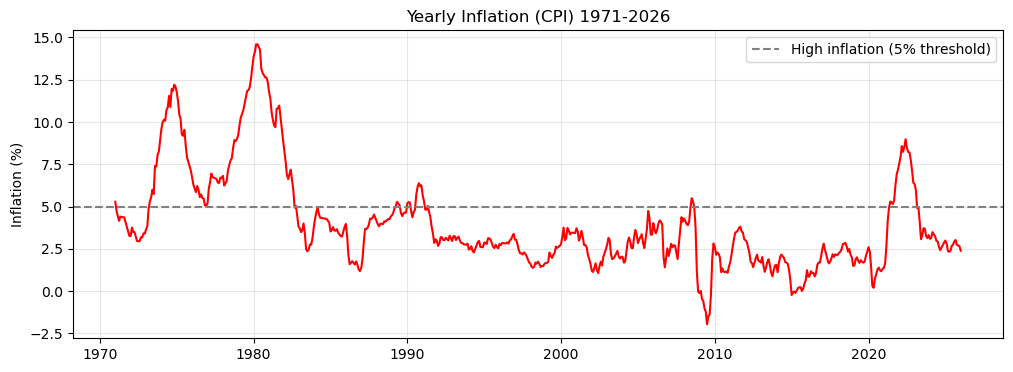

In [8]:
plt.figure(figsize=(12,4))
plt.plot(df_monthly.index, df_monthly['CPI_yearly_inflation'], color='red')
plt.axhline(y=5, color='gray', linestyle='--', label='High inflation (5% threshold)')
plt.title('Yearly Inflation (CPI) 1971-2026')
plt.ylabel('Inflation (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5.2 Inflation vs. Monthly S&P 500 Returns

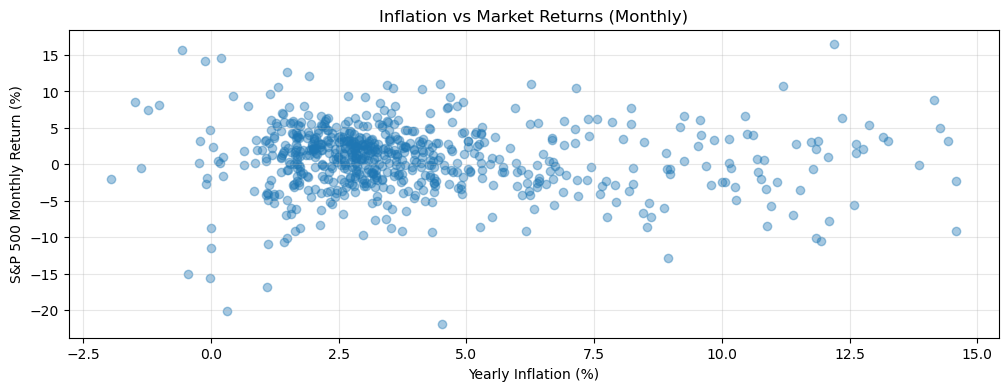

In [9]:
plt.figure(figsize=(12, 4))
plt.scatter(df_monthly['CPI_yearly_inflation'], df_monthly['Monthly_returns'], alpha=0.4)
plt.xlabel('Yearly Inflation (%)')
plt.ylabel('S&P 500 Monthly Return (%)')
plt.title('Inflation vs Market Returns (Monthly)')
plt.grid(True, alpha=0.3)
plt.show()

### 5.3 10-Year Rolling S&P 500 Returns vs. 10-Year Average Inflation

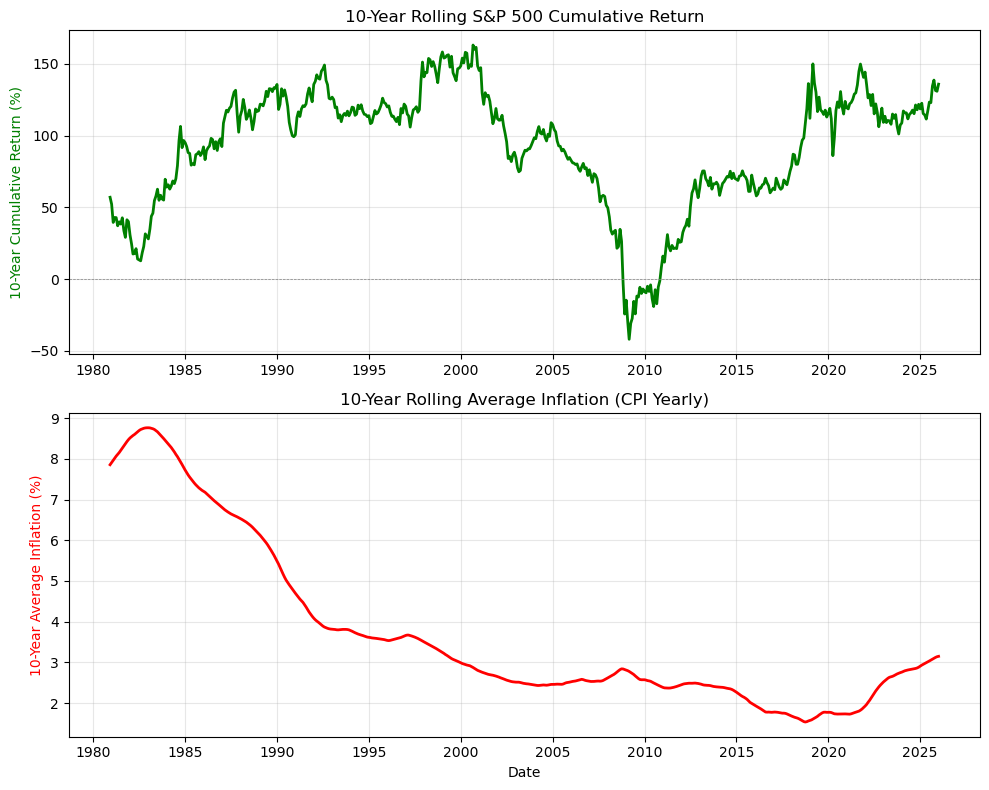

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(df_monthly.index, df_monthly['10Y_return'], color='green', linewidth=2)
ax1.set_ylabel('10-Year Cumulative Return (%)', color='green')
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax1.grid(True, alpha=0.3)
ax1.set_title('10-Year Rolling S&P 500 Cumulative Return')

ax2.plot(df_monthly.index, df_monthly['10Y_inflation'], color='red', linewidth=2)
ax2.set_ylabel('10-Year Average Inflation (%)', color='red')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.set_title('10-Year Rolling Average Inflation (CPI Yearly)')

plt.tight_layout()
plt.show()

### 5.4 Unemployment Rate vs. S&P 500 Index (Monthly)

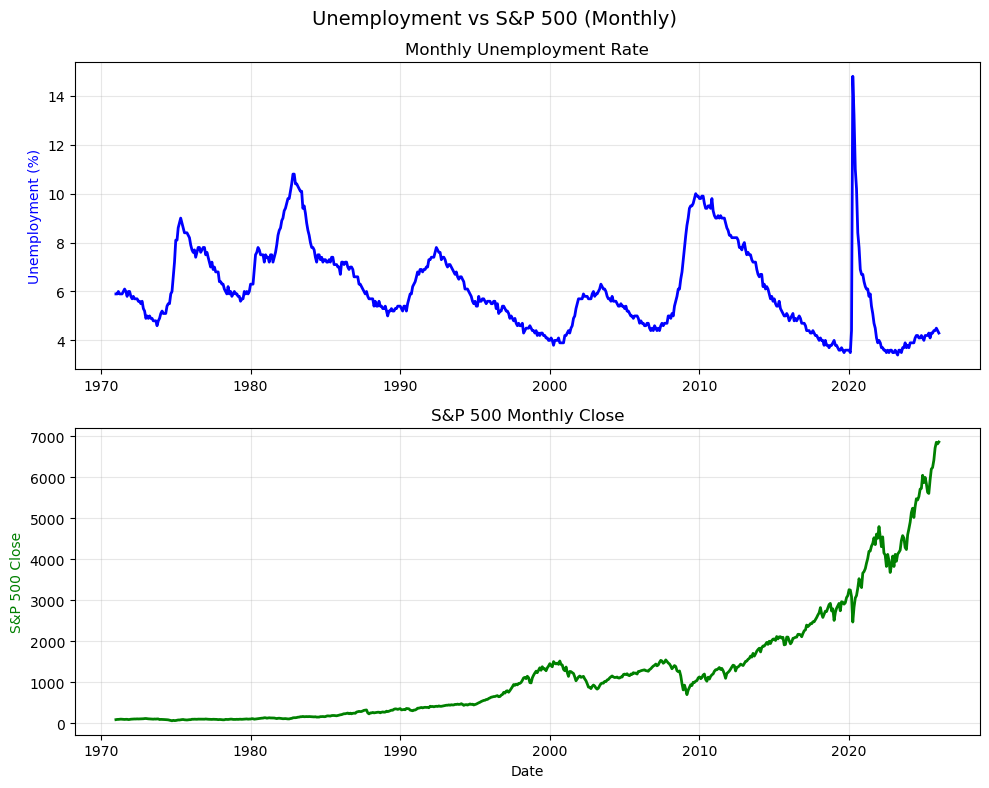

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(df_monthly.index, df_monthly['UNRATE'], color='blue', linewidth=2)
ax1.set_ylabel('Unemployment (%)', color='blue')
ax1.grid(True, alpha=0.3)
ax1.set_title('Monthly Unemployment Rate')

ax2.plot(df_monthly.index, df_monthly['GSPC'], color='green', linewidth=2)
ax2.set_ylabel('S&P 500 Close', color='green')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.set_title('S&P 500 Monthly Close')

plt.suptitle('Unemployment vs S&P 500 (Monthly)', fontsize=14)
plt.tight_layout()
plt.show()

### 5.5 Correlation Matrix

In [12]:
corr = df_monthly[['Monthly_returns', 'CPI_yearly_inflation', 'UNRATE']].corr()
print("Correlation matrix:")
print(corr)

Correlation matrix:
                      Monthly_returns  CPI_yearly_inflation  UNRATE
Monthly_returns                  1.00                 -0.07    0.05
CPI_yearly_inflation            -0.07                  1.00    0.07
UNRATE                           0.05                  0.07    1.00


### 5.6 10-Year Rolling Returns vs. Inflation Scatter

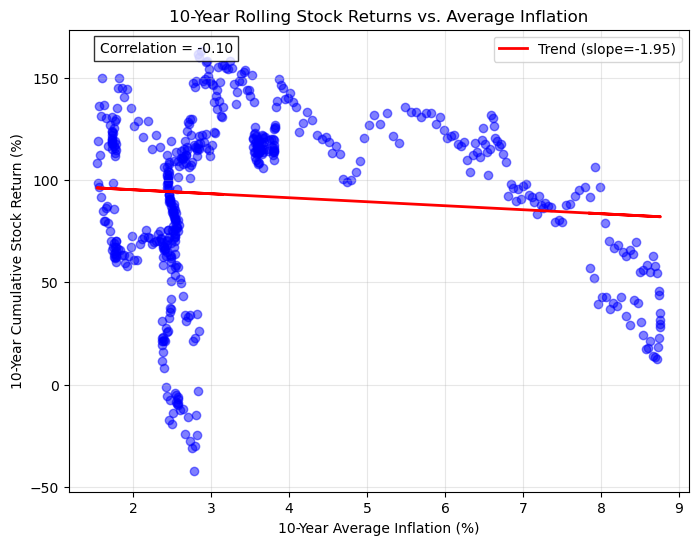

In [13]:
df_10y = df_monthly.dropna(subset=['10Y_return', '10Y_inflation'])
plt.figure(figsize=(8, 6))
plt.scatter(df_10y['10Y_inflation'], df_10y['10Y_return'], alpha=0.5, color='blue')
z = np.polyfit(df_10y['10Y_inflation'], df_10y['10Y_return'], 1)
p = np.poly1d(z)
plt.plot(df_10y['10Y_inflation'], p(df_10y['10Y_inflation']), color='red', linewidth=2, label=f'Trend (slope={z[0]:.2f})')
plt.xlabel('10-Year Average Inflation (%)')
plt.ylabel('10-Year Cumulative Stock Return (%)')
plt.title('10-Year Rolling Stock Returns vs. Average Inflation')
plt.legend()
plt.grid(True, alpha=0.3)
corr_value = df_10y['10Y_return'].corr(df_10y['10Y_inflation'])
plt.text(0.05, 0.95, f'Correlation = {corr_value:.2f}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))
plt.show()

## 6. Macro Indicators, Output Gap, Yield Curve, Recession Model

### 6.1 S&P 500 vs. Economic Output Gap

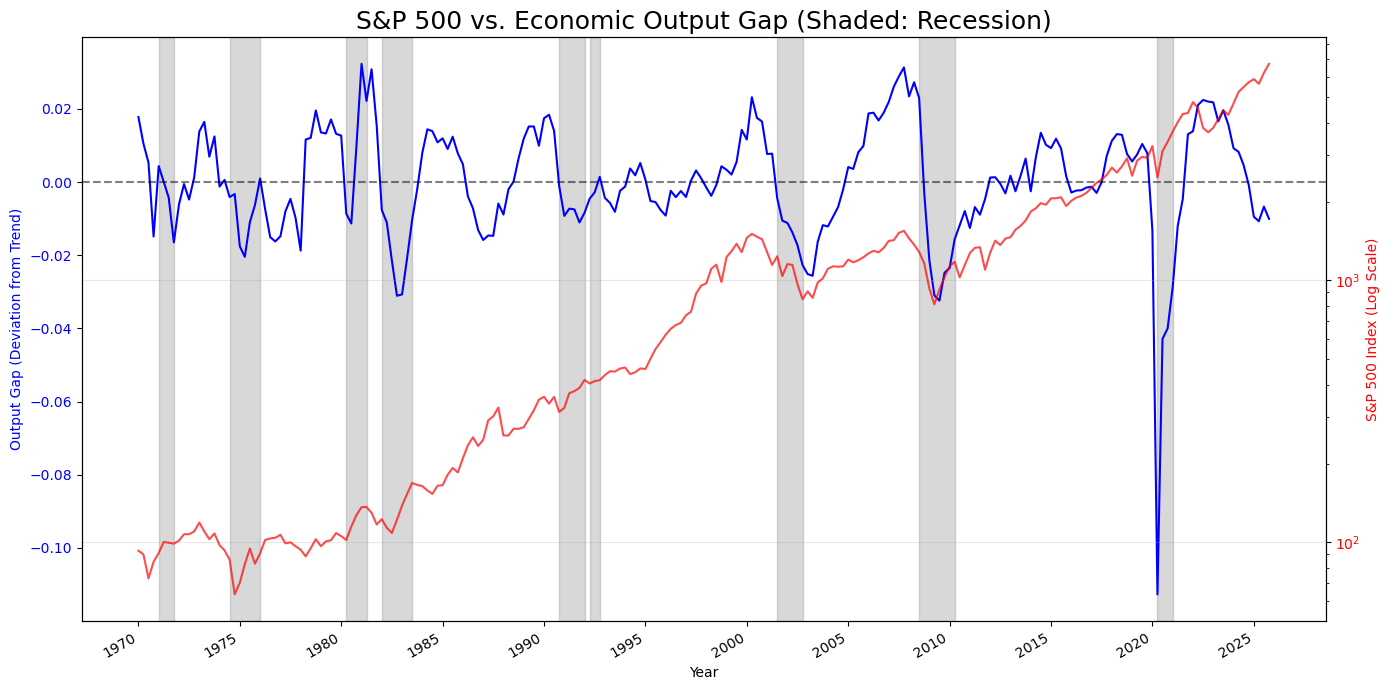

In [14]:
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(df_quarterly.index, df_quarterly['OutputGap'], color='blue', linewidth=1.5, label='Output Gap')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Output Gap (Deviation from Trend)', color='blue')
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax2 = ax1.twinx()
ax2.set_ylabel('S&P 500 Index (Log Scale)', color='red')
ax2.plot(df_quarterly.index, df_quarterly['GSPC'], color='red', linewidth=1.5, alpha=0.7, label='S&P 500')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_yscale('log')

for start, end in recession_periods:
    ax1.axvspan(start, end, color='gray', alpha=0.3)

plt.title('S&P 500 vs. Economic Output Gap (Shaded: Recession)', fontsize=18)
fig.autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 S&P 500 vs. Yield Curve

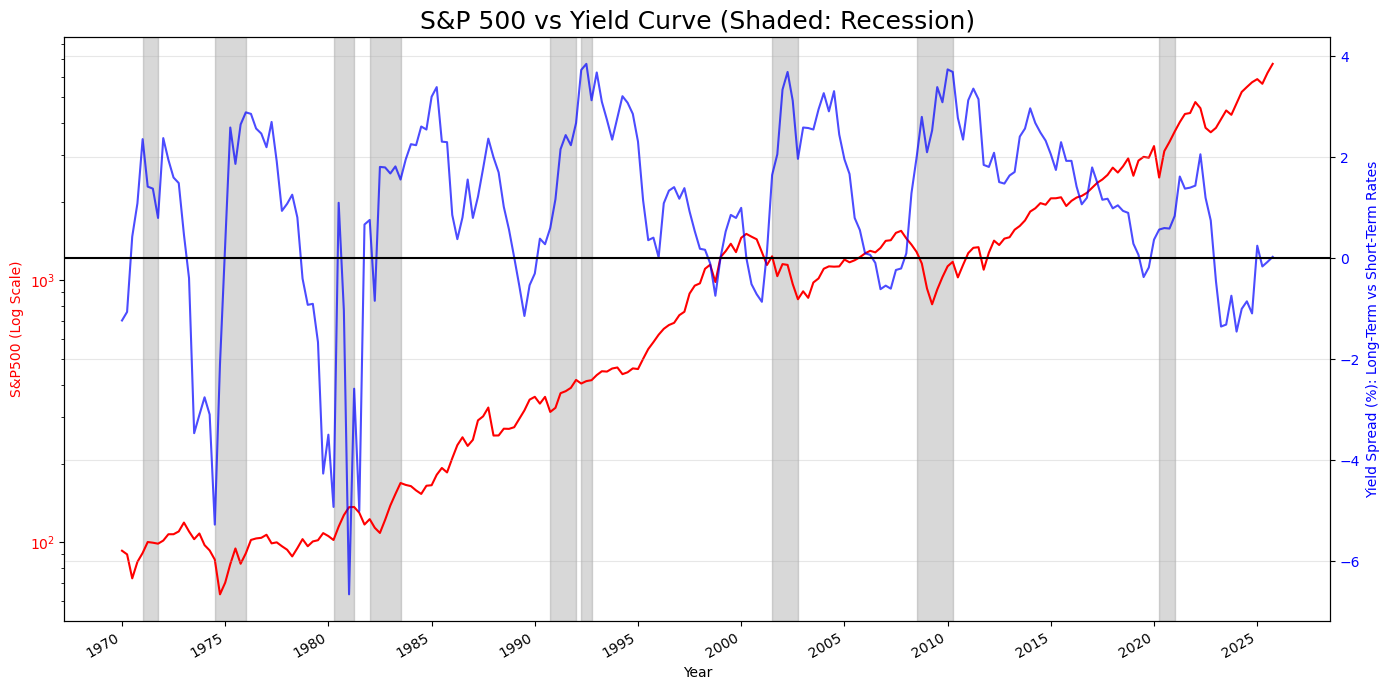

In [15]:
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(df_quarterly.index, df_quarterly['GSPC'], color='red', linewidth=1.5, label='S&P500 Index')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_yscale('log')
ax1.set_xlabel('Year')
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_ylabel('S&P500 (Log Scale)', color='red')

ax2 = ax1.twinx()
ax2.plot(df_quarterly.index, df_quarterly['YieldSpread'], color='blue', linewidth=1.5, alpha=0.7, label='Yield Spread (%)')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='black', linestyle='-')
ax2.set_ylabel('Yield Spread (%): Long-Term vs Short-Term Rates', color='blue')

for start, end in recession_periods:
    ax1.axvspan(start, end, color='gray', alpha=0.3)

plt.title('S&P 500 vs Yield Curve (Shaded: Recession)', fontsize=18)
fig.autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Recession Probability Model (Logistic Regression)

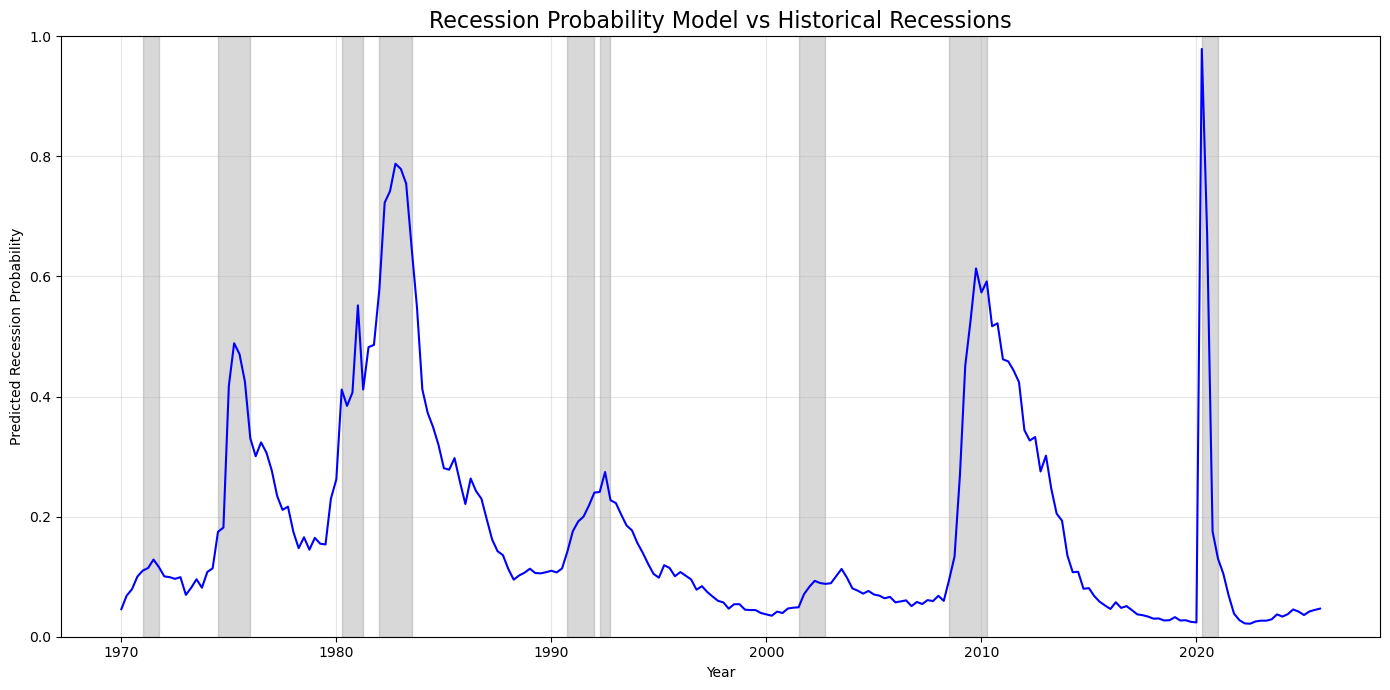

Regression Results:
Intercept: -1.87
YieldSpread   -0.08
UNRATE         1.20
FEDFUNDS       0.21
dtype: float64


In [16]:
# Prepare data (drop NaN in relevant columns)
model_df = df_quarterly[['YieldSpread', 'UNRATE', 'FEDFUNDS', 'RECESSION']].dropna()
Y = model_df['RECESSION']
X = model_df[['YieldSpread', 'UNRATE', 'FEDFUNDS']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, Y)

# Predict probabilities
df_quarterly.loc[model_df.index, 'Prob'] = model.predict_proba(X_scaled)[:, 1]

# Plot
plt.figure(figsize=(14, 7))
plt.plot(df_quarterly.index, df_quarterly['Prob'], label='Model Recession Probability', color='blue', linewidth=1.5)
for start, end in recession_periods:
    plt.axvspan(start, end, color='gray', alpha=0.3)
plt.title('Recession Probability Model vs Historical Recessions', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Predicted Recession Probability')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Regression Results:")
print(f"Intercept: {model.intercept_[0]:.2f}")
coefs = pd.Series(model.coef_[0], index=X.columns)
print(coefs)

### 6.4 Sector Sensitivity to GDP Growth

In [17]:
# Create sector returns from df_stocks (quarterly aggregation)
# Get list of tickers per sector from df_sectors
sector_tickers = df_sectors.reset_index().groupby('Sector')['Ticker'].apply(list).to_dict()

# Quarterly returns for each ticker (using df_stocks)
quarterly_stock_returns = df_stocks.set_index('Date').groupby('Ticker')['Returns'].resample('QS').apply(lambda x: (1+x).prod() - 1).unstack()

# Align with quarterly GDP growth
gdp_growth = df_quarterly['GDPGrowth'].dropna()
common_idx = quarterly_stock_returns.index.intersection(gdp_growth.index)
quarterly_stock_returns = quarterly_stock_returns.loc[common_idx]
gdp_growth_aligned = gdp_growth.loc[common_idx]

sector_correlations = {}
for sector, tickers in sector_tickers.items():
    available = [t for t in tickers if t in quarterly_stock_returns.columns]
    if available:
        sector_returns = quarterly_stock_returns[available].mean(axis=1)
        sector_correlations[sector] = sector_returns.corr(gdp_growth_aligned)

# Plot
ax = pd.Series(sector_correlations).sort_values().plot(kind='barh', color='blue')
ax.bar_label(ax.containers[0], fmt='%.2f', label_type='center', color='white', fontweight='bold')
plt.title('Sector Sensitivity: Correlation with GDP Growth')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

TypeError: no numeric data to plot

## 7. Yield Curve Slope, GDP Change Smoothing, Volume Smoothing

### 7.1 10-Year Treasury Yield Slope Proxy (Difference over 63 days)

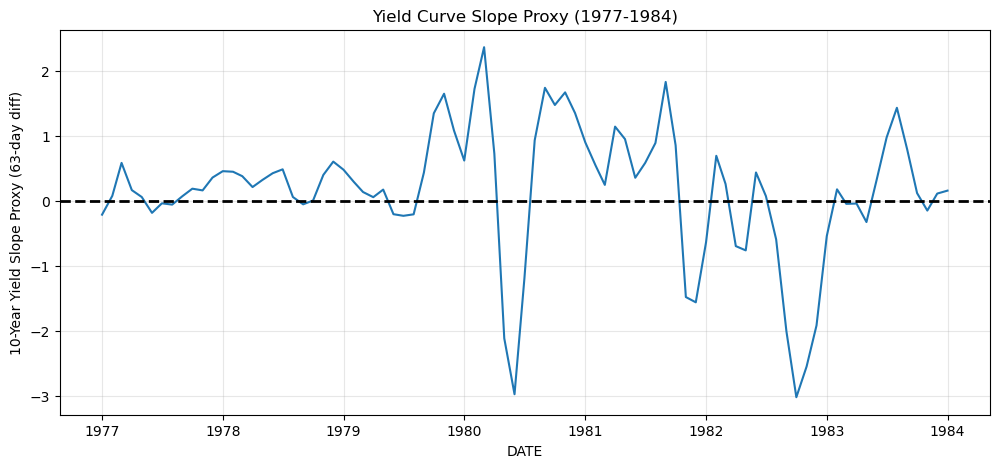

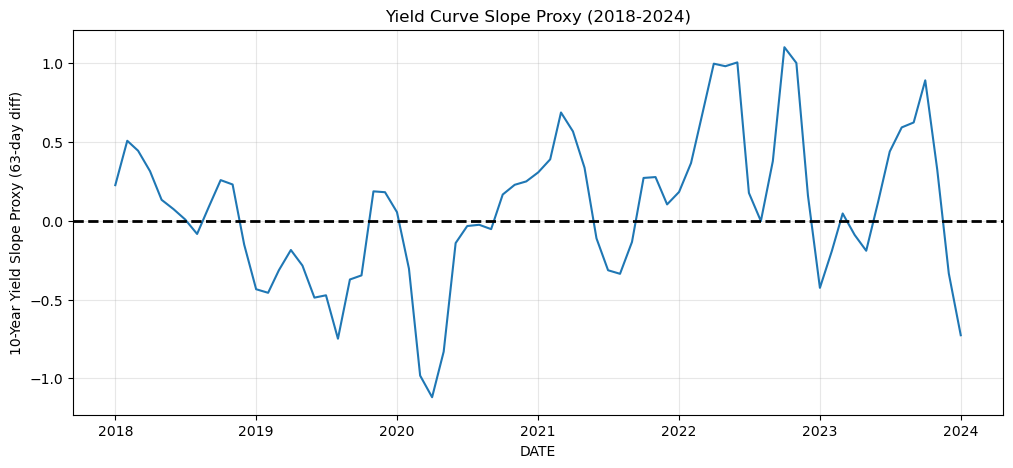

In [18]:
# Use daily df_master to compute slope proxy
df_yield = df_master[['DGS10']].dropna().copy()
df_yield['DGS10_change'] = df_yield['DGS10'].diff()
df_yield['DGS10_smoothed'] = smooth_series(df_yield, 'DGS10_change', 80)
df_yield['DGS10_slope_proxy'] = df_yield['DGS10'].diff(63)

# Convert index to column for slicing
df_yield_reset = df_yield.reset_index().rename(columns={'index':'DATE'})

# Plot 1977-1984 period
plt.figure(figsize=(12,5))
data_slice = slice_dates(monthly_resample(df_yield_reset, date_col='DATE', value_col='DGS10_slope_proxy'), 
                         '1977-01-01', '1984-01-01').dropna()
sns.lineplot(data=data_slice, x='DATE', y='DGS10_slope_proxy')
plt.ylabel('10-Year Yield Slope Proxy (63-day diff)')
horizontal_rule()
plt.title('Yield Curve Slope Proxy (1977-1984)')
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2018-2024 period
plt.figure(figsize=(12,5))
data_slice = slice_dates(monthly_resample(df_yield_reset, date_col='DATE', value_col='DGS10_slope_proxy'), 
                         '2018-01-01', '2024-01-01').dropna()
sns.lineplot(data=data_slice, x='DATE', y='DGS10_slope_proxy')
plt.ylabel('10-Year Yield Slope Proxy (63-day diff)')
horizontal_rule()
plt.title('Yield Curve Slope Proxy (2018-2024)')
plt.grid(True, alpha=0.3)
plt.show()

### 7.2 GDP Change Smoothing

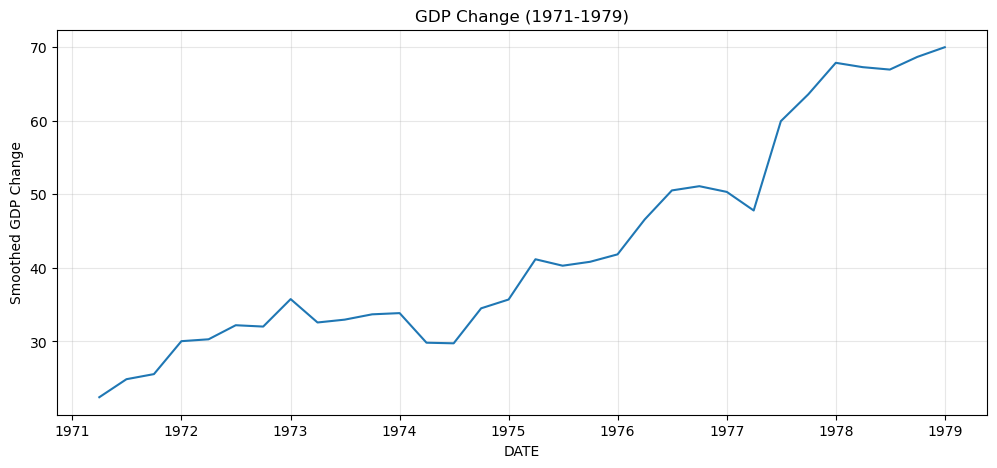

In [19]:
df_gdp_local = df_gdp.reset_index().rename(columns={'DATE':'DATE'})
df_gdp_local['GDP_change'] = df_gdp_local['GDP'].diff()
df_gdp_local['GDP_smooth'] = smooth_series(df_gdp_local, 'GDP_change', 8)

plt.figure(figsize=(12,5))
data_slice = slice_dates(monthly_resample(df_gdp_local, date_col='DATE', value_col='GDP_smooth'), 
                         '1971-01-01', '1979-01-01').dropna()
sns.lineplot(data=data_slice, x='DATE', y='GDP_smooth')
plt.ylabel('Smoothed GDP Change')
plt.title('GDP Change (1971-1979)')
plt.grid(True, alpha=0.3)
plt.show()

### 7.3 S&P 500 Trading Volume Smoothing

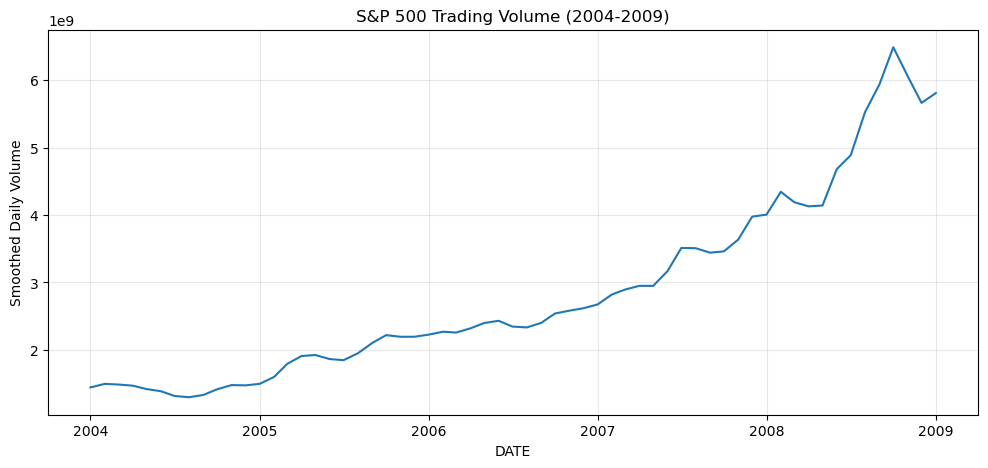

In [20]:
# Use df_sp500_index (daily) to compute volume smoothing
df_volume = df_sp500_index[['Volume']].dropna().copy()
df_volume['volume_smooth'] = smooth_series(df_volume, 'Volume', 63)
df_volume_reset = df_volume.reset_index().rename(columns={'DATE':'DATE'})

plt.figure(figsize=(12,5))
data_slice = slice_dates(monthly_resample(df_volume_reset, date_col='DATE', value_col='volume_smooth'), 
                         '2004-01-01', '2009-01-01').dropna()
sns.lineplot(data=data_slice, x='DATE', y='volume_smooth')
plt.ylabel('Smoothed Daily Volume')
plt.title('S&P 500 Trading Volume (2004-2009)')
plt.grid(True, alpha=0.3)
plt.show()

## 8. Seasonality, Yearly Trends, Sector/Industry/Company Performance

### 8.1 Monthly Seasonality: Returns and Volatility

Monthly Returns Summary:
            mean_return  std_return
Month_Name                         
January            0.00        0.02
February           0.00        0.02
March              0.00        0.02
April              0.00        0.02
May                0.00        0.02
June               0.00        0.02
July               0.00        0.02
August             0.00        0.02
September         -0.00        0.02
October            0.00        0.03
November           0.00        0.02
December           0.00        0.02


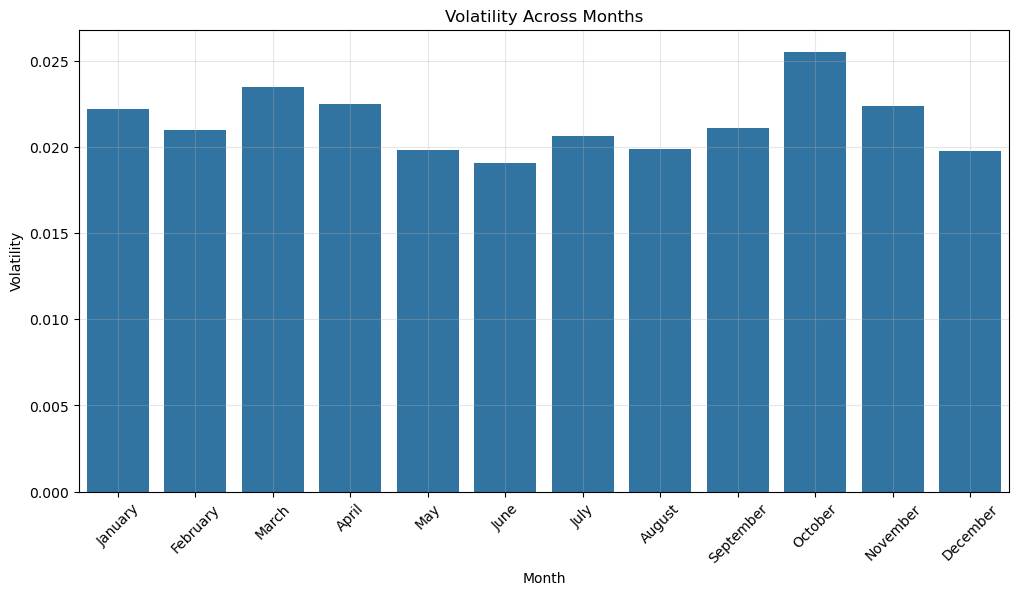

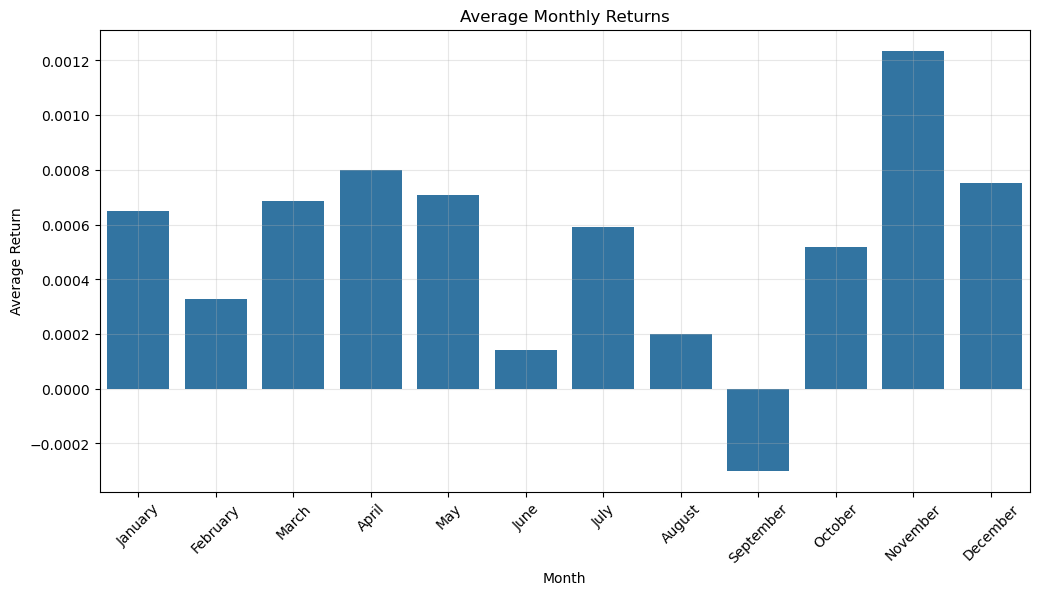

In [21]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_returns_agg = df_stocks.groupby('Month_Name')['Returns'].agg(mean_return='mean', std_return='std').reindex(month_order)
monthly_volatility = df_stocks.groupby('Month_Name')['Returns'].std().reindex(month_order)

print("Monthly Returns Summary:")
print(monthly_returns_agg)

# Plot monthly volatility
plt.figure(figsize=(12,6))
sns.barplot(x=monthly_volatility.index, y=monthly_volatility.values)
plt.xticks(rotation=45)
plt.title('Volatility Across Months')
plt.ylabel('Volatility')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.show()

# Plot average monthly returns
plt.figure(figsize=(12,6))
sns.barplot(x=monthly_returns_agg.index, y=monthly_returns_agg['mean_return'])
plt.xticks(rotation=45)
plt.title('Average Monthly Returns')
plt.ylabel('Average Return')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.show()

### 8.2 Yearly Performance Trends

      mean_return  volatility
Year                         
1970        -0.00        0.02
1971         0.00        0.02
1972         0.00        0.02
1973        -0.00        0.02
1974        -0.00        0.03


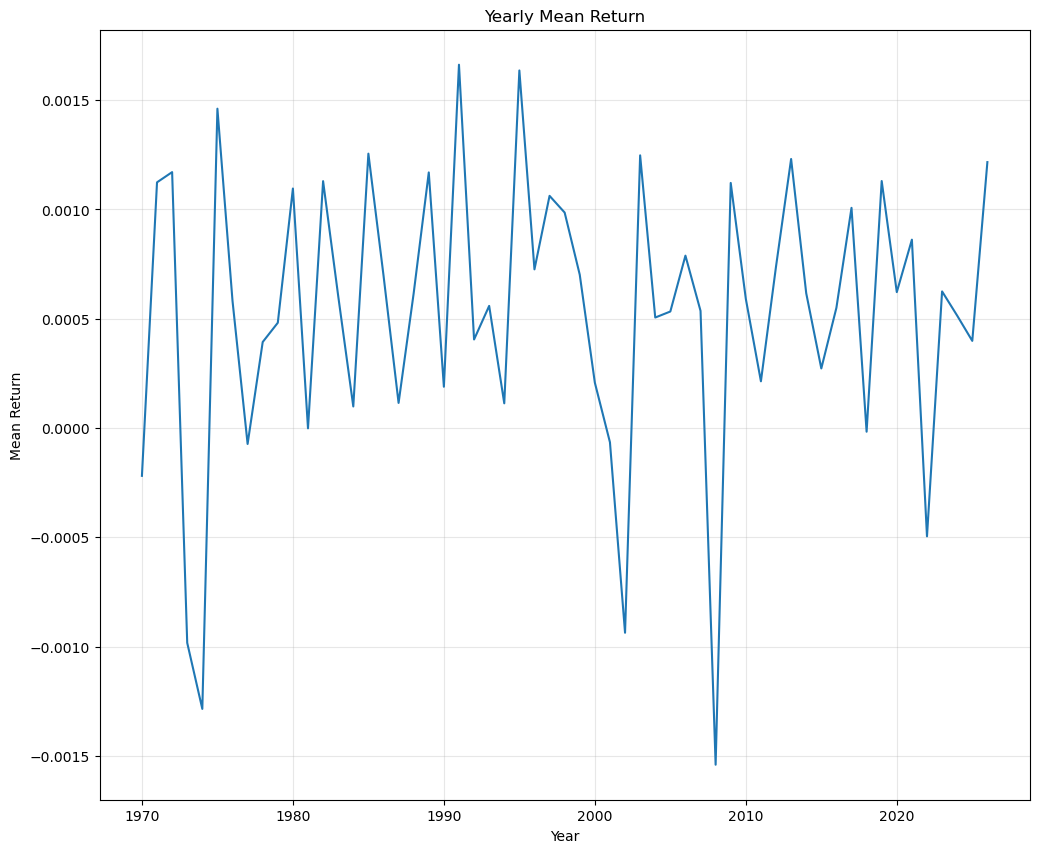

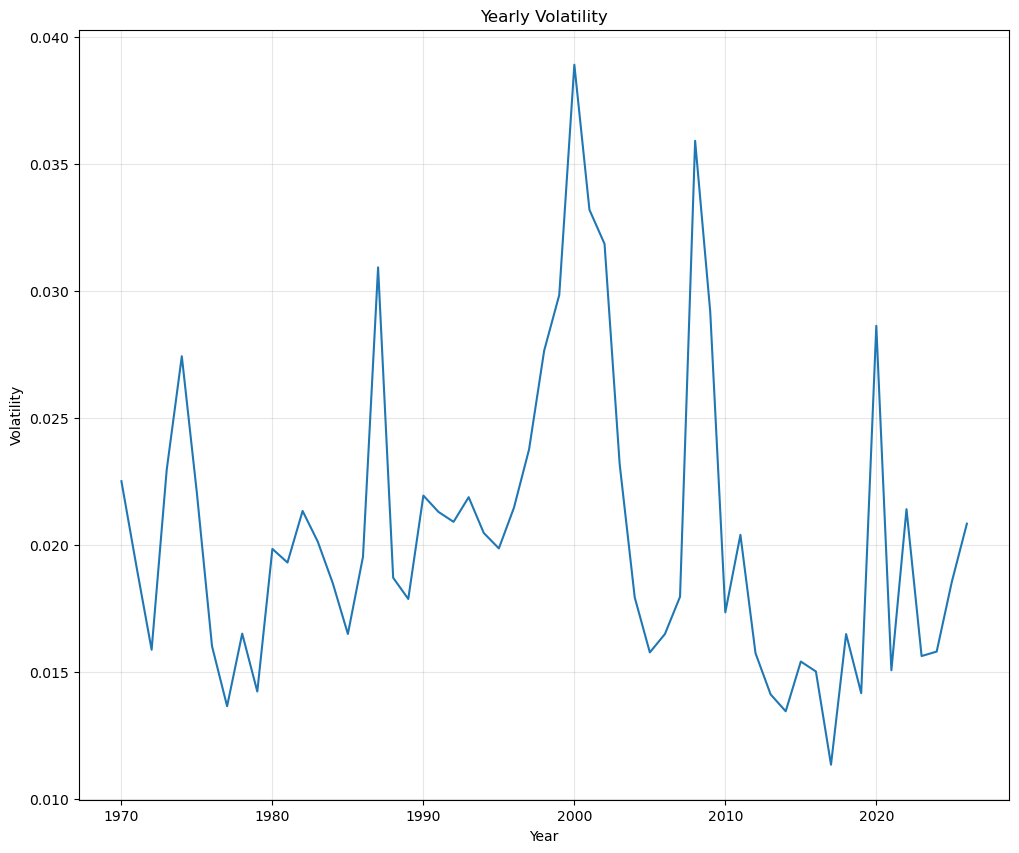

In [22]:
yearly_performance = df_stocks.groupby('Year')['Returns'].agg(mean_return='mean', volatility='std')
print(yearly_performance.head())

plt.figure(figsize=(12, 10))
plt.plot(yearly_performance['mean_return'])
plt.title('Yearly Mean Return')
plt.grid(True, alpha=0.3)
plt.xlabel('Year')
plt.ylabel('Mean Return')
plt.show()

plt.figure(figsize=(12, 10))
plt.plot(yearly_performance['volatility'])
plt.title('Yearly Volatility')
plt.grid(True, alpha=0.3)
plt.xlabel('Year')
plt.ylabel('Volatility')
plt.show()

### 8.3 Monthly vs Yearly Heatmap

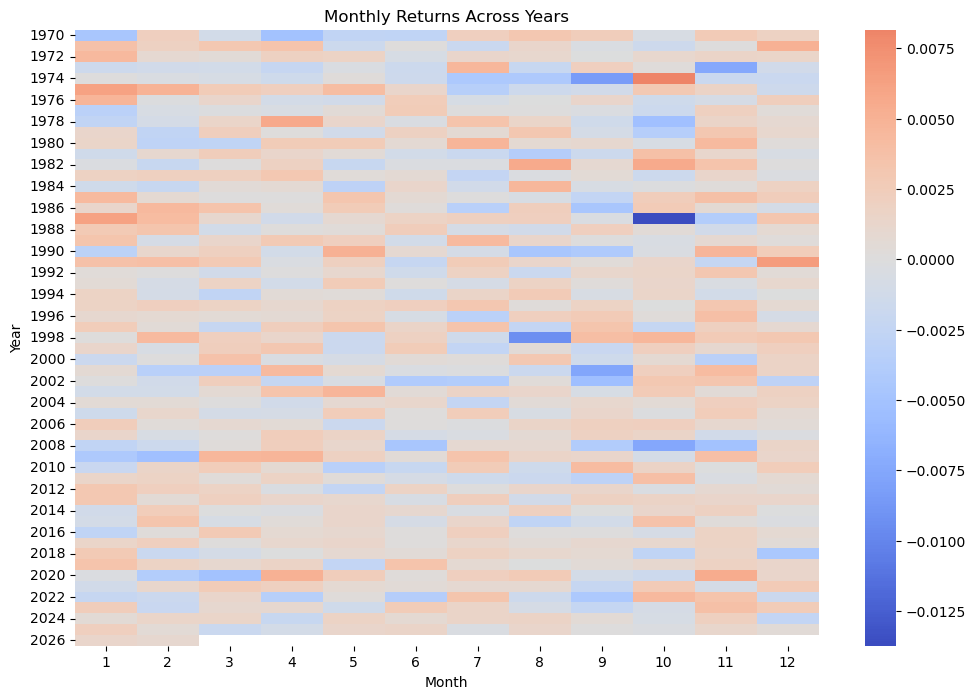

In [23]:
monthly_yearly_pivot = df_stocks.pivot_table(values='Returns', index='Year', columns='Month', aggfunc='mean')
plt.figure(figsize=(12,8))
sns.heatmap(monthly_yearly_pivot, cmap='coolwarm', center=0)
plt.title("Monthly Returns Across Years")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

### 8.4 Sector-Level Analysis

In [24]:
sector_summary = df_stocks.groupby('Sector')['Returns'].agg(mean_return='mean', volatility='std').reset_index()
print("Sector Summary:")
print(sector_summary)

# Best and worst performing sectors
sector_performance = df_stocks.groupby('Sector')['Returns'].mean().sort_values(ascending=False)
sector_risk = df_stocks.groupby('Sector')['Returns'].std().sort_values(ascending=False)

print("\nBest performing sectors:")
print(sector_performance.head())
print("\nMost risky sectors (highest volatility):")
print(sector_risk.head())

# Sector returns vs risk scatter
plt.figure(figsize=(10,6))
sns.scatterplot(data=sector_summary, x='volatility', y='mean_return', hue='Sector', s=100)
for i, row in sector_summary.iterrows():
    plt.text(row['volatility'], row['mean_return'], row['Sector'], fontsize=8)
plt.xlabel('Volatility (Risk)')
plt.ylabel('Average Return')
plt.title('Risk vs Return by Sector')
plt.grid(True, alpha=0.3)
plt.show()

# Rolling volatility by sector
sector_vol = df_stocks.groupby('Sector')[['30_days_vol','60_days_vol','252_days_vol']].mean()
sector_vol.plot(kind='bar', figsize=(10,6))
plt.title('Average Rolling Volatility by Sector')
plt.ylabel('Volatility')
plt.grid(True, alpha=0.3)
plt.show()

# Sector monthly seasonality heatmap
sector_monthly = df_stocks.groupby(['Sector', 'Month_Name'])['Returns'].mean().unstack().reindex(columns=month_order)
plt.figure(figsize=(12,6))
sns.heatmap(sector_monthly, cmap='coolwarm', center=0)
plt.title("Sector Monthly Seasonality")
plt.show()

KeyError: 'Sector'

### 8.5 Industry-Level Analysis (Top 10 by returns)

In [25]:
industry_performance = df_stocks.groupby('Industry')['Returns'].mean().sort_values(ascending=False)
industry_risk = df_stocks.groupby('Industry')['Returns'].std().sort_values(ascending=False)

print("Top 10 industries by average return:")
print(industry_performance.head(10))
print("\nTop 10 riskiest industries:")
print(industry_risk.head(10))

# Plot top 10 industries by return
plt.figure(figsize=(8,6))
industry_performance.head(10).plot(kind='bar', title='Average Returns by Industry')
plt.grid(True, alpha=0.3)
plt.show()

# Rolling volatility by industry (top 10 for readability)
industry_vol = df_stocks.groupby('Industry')[['30_days_vol','60_days_vol','252_days_vol']].mean()
industry_vol_sorted = industry_vol.mean(axis=1).sort_values(ascending=False).head(10)
industry_vol.loc[industry_vol_sorted.index].plot(kind='bar', figsize=(12,6))
plt.title('Average Rolling Volatility by Industry (Top 10)')
plt.ylabel('Volatility')
plt.grid(True, alpha=0.3)
plt.show()

KeyError: 'Industry'

### 8.6 Company-Level Analysis (Top 10 by returns)

Top 10 companies by average return:
Name
Broadcom Inc.              0.00
NVIDIA Corporation         0.00
Netflix, Inc.              0.00
Amazon.com, Inc.           0.00
Mastercard Incorporated    0.00
The Home Depot, Inc.       0.00
Alphabet Inc.              0.00
Microsoft Corporation      0.00
Intuitive Surgical, Inc.   0.00
Meta Platforms, Inc.       0.00
Name: Returns, dtype: float64

Top 10 riskiest companies:
Name
Regeneron Pharmaceuticals, Inc.       0.04
Booking Holdings Inc.                 0.04
NVIDIA Corporation                    0.04
Equinix, Inc.                         0.04
Netflix, Inc.                         0.03
Amazon.com, Inc.                      0.03
Vertex Pharmaceuticals Incorporated   0.03
Adobe Inc.                            0.03
Applied Materials, Inc.               0.03
QUALCOMM Incorporated                 0.03
Name: Returns, dtype: float64


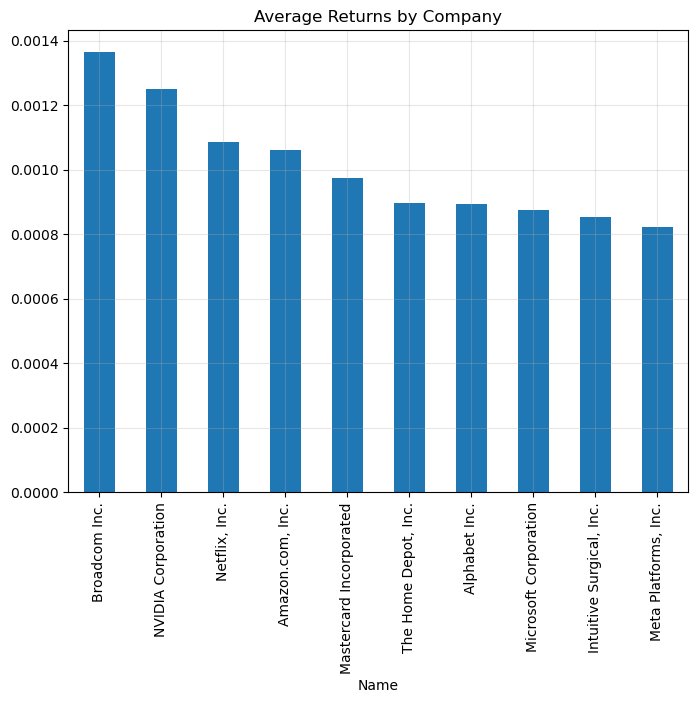

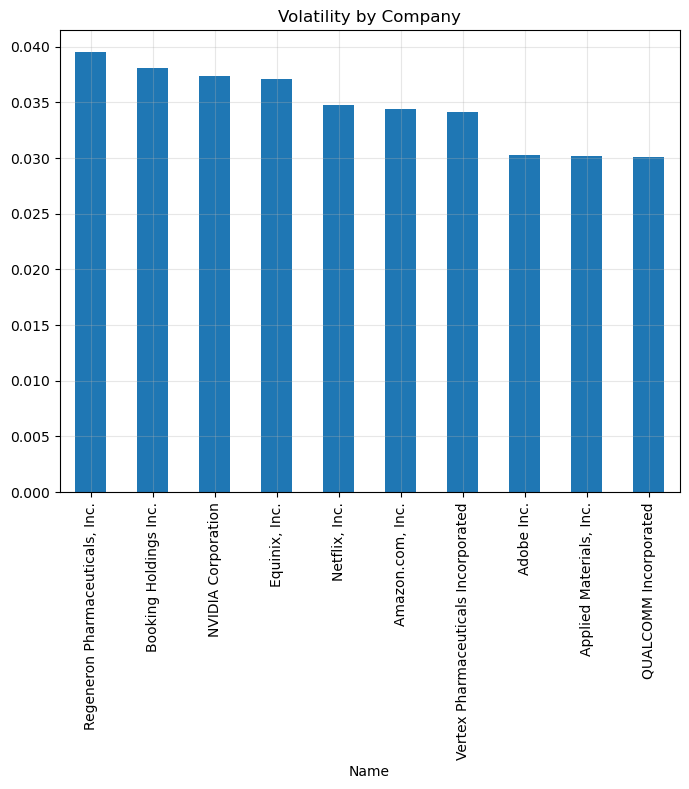

In [26]:
company_performance = df_stocks.groupby('Name')['Returns'].mean().sort_values(ascending=False)
company_risk = df_stocks.groupby('Name')['Returns'].std().sort_values(ascending=False)

print("Top 10 companies by average return:")
print(company_performance.head(10))
print("\nTop 10 riskiest companies:")
print(company_risk.head(10))

plt.figure(figsize=(8,6))
company_performance.head(10).plot(kind='bar', title='Average Returns by Company')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,6))
company_risk.head(10).plot(kind='bar', title='Volatility by Company')
plt.grid(True, alpha=0.3)
plt.show()